<a href="https://colab.research.google.com/github/rifat01-rahman/Timse_Series_forecasting-/blob/main/Time_series_with_pytorch_(Chapter_2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
from random import gauss, random

import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.filters.hp_filter import hpfilter
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

from scipy import signal, stats

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path


In [ ]:
from google.colab import files
uploaded = files.upload()  # opens a file picker, choose bugatti_sales.csv

Saving bugatti_sales.csv to bugatti_sales.csv


In [ ]:
warnings.filterwarnings('ignore', category=DeprecationWarning,
                        message='.*DataFrameGroupBy.apply operated on the grouping columns.*')

In [ ]:
# -----------------------------------------------------------------------------
# Palette, line styles, and figure defaults
# -----------------------------------------------------------------------------
custom_palette = ["#000000", "#0072B2", "#D55E00", "#009E73",
                  "#CC79A7", "#56B4E9", "#E69F00"]
line_styles = ['-', '--', '-.', ':']

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Source Sans Pro', 'Arial']
plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['axes.titlesize'] = 18


class CFG:
    data_folder = Path("/content")
    img_dim1 = 12
    img_dim2 = 6
    fontsize = 18

CFG.data_folder
plt.rcParams.update({'figure.figsize': (CFG.img_dim1, CFG.img_dim2)})

In [ ]:
# =============================================================================
# 2.1  What is time series? – Gapminder life expectancy
# =============================================================================

url = "https://raw.githubusercontent.com/plotly/datasets/master/gapminderDataFiveYear.csv"
df = pd.read_csv(url)

In [ ]:
df.head(5)

,country,year,pop,continent,lifeExp,gdpPercap
0,Afghanistan,1952,8425333.0,Asia,28.801,779.445314
1,Afghanistan,1957,9240934.0,Asia,30.332,820.853030
2,Afghanistan,1962,10267083.0,Asia,31.997,853.100710
3,Afghanistan,1967,11537966.0,Asia,34.020,836.197138
4,Afghanistan,1972,13079460.0,Asia,36.088,739.981106


In [ ]:
# Group life expectancy by continent and year
world_lifexp = df.groupby(["continent", "year"])["lifeExp"].median().reset_index()
print(world_lifexp.head(n=5))


  continent  year  lifeExp
0    Africa  1952  38.8330
1    Africa  1957  40.5925
2    Africa  1962  42.6305
3    Africa  1967  44.6985
4    Africa  1972  47.0315


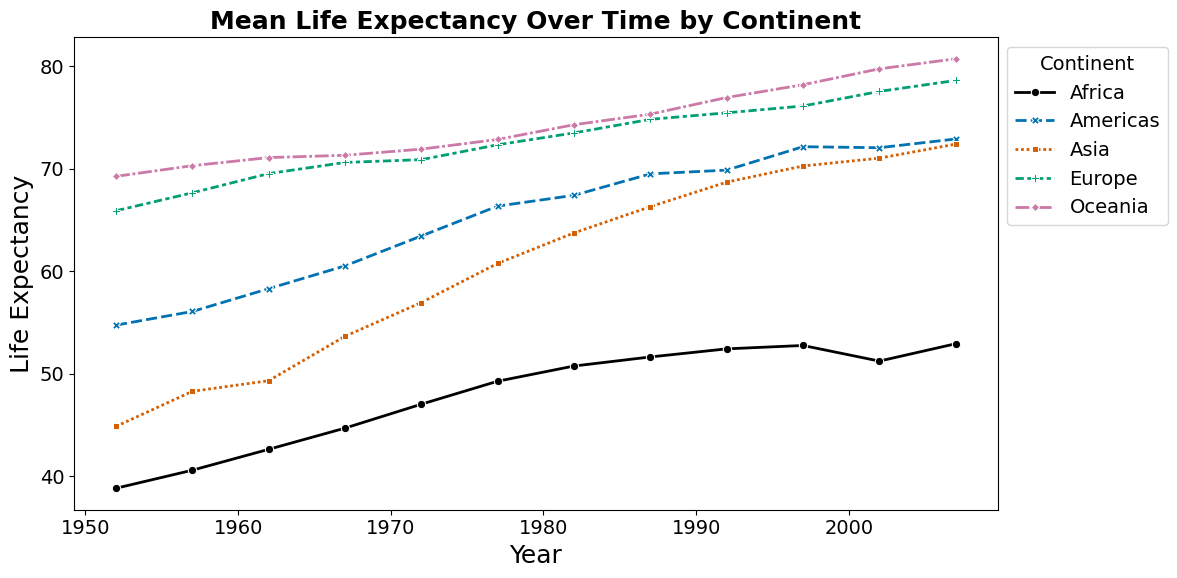

In [ ]:
# --- Figure 2.1: Life expectancy by continent over time ---
fig, ax = plt.subplots(figsize=(CFG.img_dim1, CFG.img_dim2))
sns.lineplot(
    data=world_lifexp,
    x="year", y="lifeExp",
    hue="continent", style="continent",
    palette=custom_palette[:5],
    markers=True, dashes=True,
    ax=ax
)
ax.set_title("Mean Life Expectancy Over Time by Continent",
             fontsize=18, fontweight='bold')
ax.set_xlabel("Year", fontsize=18)
ax.set_ylabel("Life Expectancy", fontsize=18)
ax.legend(title="Continent", bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [ ]:
# =============================================================================
# 2.2  Missing data – Bugatti sales
# =============================================================================

df = pd.read_csv(CFG.data_folder / 'bugatti_sales.csv')
print(df.head(n=5))

   year month  sales
0  2016   Mar      1
1  2016   Apr      2
2  2016   Sep      2
3  2016   Nov      1
4  2016   Dec      1


In [ ]:
# --- Resample to monthly and zero-fill ---
df['date'] = pd.to_datetime(df['year'].astype(str) + '-' + df['month'],
                            format='%Y-%b')
df = df.set_index('date').resample('ME').sum().fillna(0)
df = df.drop(['year', 'month'], axis=1)
df = df.reset_index()
print(df.head(n=5))

        date  sales
0 2016-03-31      1
1 2016-04-30      2
2 2016-05-31      0
3 2016-06-30      0
4 2016-07-31      0


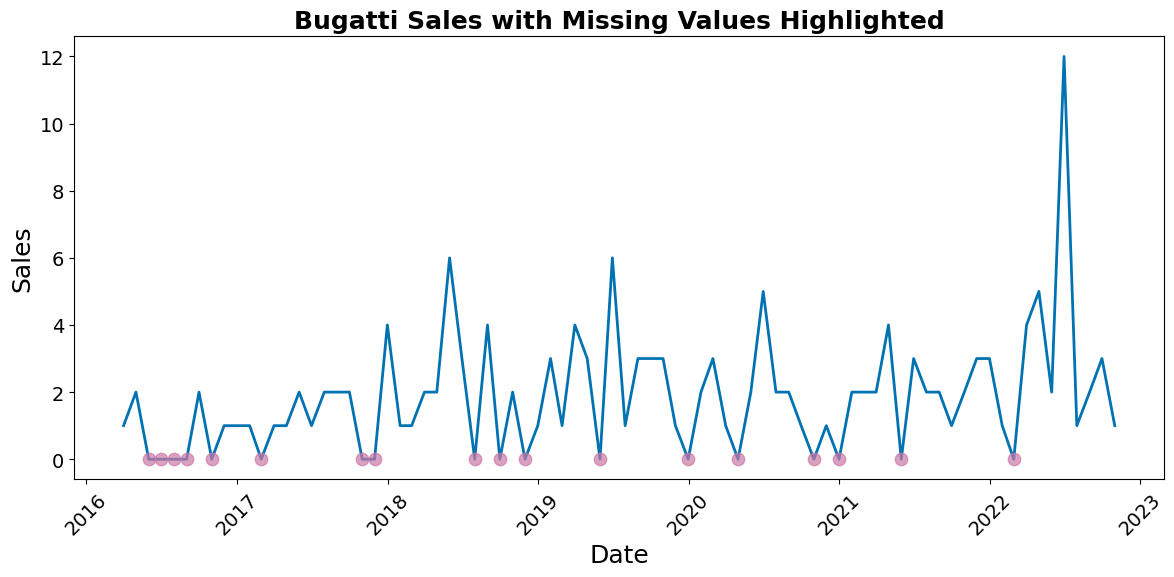

In [ ]:
# --- Figure 2.2: Bugatti sales with missing values highlighted ---
fig, ax = plt.subplots(figsize=(CFG.img_dim1, CFG.img_dim2))
sns.lineplot(data=df, x="date", y="sales", color=custom_palette[1])
ax.set_xlabel('Date', fontsize=18)
ax.set_ylabel('Sales', fontsize=18)
ax.set_title('Bugatti Sales with Missing Values Highlighted',
             fontsize=18, fontweight='bold')
zero_points = df[df['sales'] == 0]
plt.scatter(zero_points['date'], zero_points['sales'],
            color=custom_palette[4], zorder=5, alpha=0.7, s=80)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# 2.3  M5 data – loading and preparation
# =============================================================================

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving M5_t20_ABC.csv to M5_t20_ABC.csv


In [ ]:
panel_df = pd.read_csv(CFG.data_folder / 'M5_t20_ABC.csv',
                       index_col=False).drop(columns='Unnamed: 0')
panel_df['date'] = pd.to_datetime(panel_df['date'])
panel_df.set_index('date')

,id,item_id,dept_id,cat_id,state_id,sold,sell_price,count,ABC_class
date,,,,,,,,,
2011-01-29,FOODS_2_197_CA_3_evaluation,FOODS_2_197,FOODS_2,FOODS,CA,39,2.98,1969,A
2011-01-30,FOODS_2_197_CA_3_evaluation,FOODS_2_197,FOODS_2,FOODS,CA,65,2.98,1969,A
2011-01-31,FOODS_2_197_CA_3_evaluation,FOODS_2_197,FOODS_2,FOODS,CA,32,2.98,1969,A
2011-02-01,FOODS_2_197_CA_3_evaluation,FOODS_2_197,FOODS_2,FOODS,CA,44,2.98,1969,A
2011-02-02,FOODS_2_197_CA_3_evaluation,FOODS_2_197,FOODS_2,FOODS,CA,46,2.98,1969,A
...,...,...,...,...,...,...,...,...,...
2016-06-15,HOUSEHOLD_2_437_CA_3_evaluation,HOUSEHOLD_2_437,HOUSEHOLD_2,HOUSEHOLD,CA,0,7.97,1969,C
2016-06-16,HOUSEHOLD_2_437_CA_3_evaluation,HOUSEHOLD_2_437,HOUSEHOLD_2,HOUSEHOLD,CA,0,7.97,1969,C
2016-06-17,HOUSEHOLD_2_437_CA_3_evaluation,HOUSEHOLD_2_437,HOUSEHOLD_2,HOUSEHOLD,CA,0,7.97,1969,C


In [ ]:
panel_df.isnull().sum().sum()

np.int64(0)

In [ ]:
def remove_tail(df, drop_value=28):
    assert 'item_id' in df.columns and 'date' in df.columns
    df_sorted = df.sort_values(['item_id', 'date'])

    def remove_tail_values(group):
        return group.iloc[:-drop_value]

    df_filter = (df_sorted.groupby('item_id')
                 .apply(remove_tail_values, include_groups=True)
                 .reset_index(drop=True))
    return df_filter

In [ ]:
panel_df = remove_tail(panel_df, drop_value=28).copy()

In [ ]:
panel_df

,id,item_id,dept_id,cat_id,state_id,sold,date,sell_price,count,ABC_class
0,FOODS_1_082_CA_3_evaluation,FOODS_1_082,FOODS_1,FOODS,CA,0,2011-01-29,0.98,1969,C
1,FOODS_1_082_CA_3_evaluation,FOODS_1_082,FOODS_1,FOODS,CA,0,2011-01-30,0.98,1969,C
2,FOODS_1_082_CA_3_evaluation,FOODS_1_082,FOODS_1,FOODS,CA,0,2011-01-31,0.98,1969,C
3,FOODS_1_082_CA_3_evaluation,FOODS_1_082,FOODS_1,FOODS,CA,0,2011-02-01,0.98,1969,C
4,FOODS_1_082_CA_3_evaluation,FOODS_1_082,FOODS_1,FOODS,CA,0,2011-02-02,0.98,1969,C
...,...,...,...,...,...,...,...,...,...,...
116455,HOUSEHOLD_2_437_CA_3_evaluation,HOUSEHOLD_2_437,HOUSEHOLD_2,HOUSEHOLD,CA,3,2016-05-18,7.97,1969,C
116456,HOUSEHOLD_2_437_CA_3_evaluation,HOUSEHOLD_2_437,HOUSEHOLD_2,HOUSEHOLD,CA,1,2016-05-19,7.97,1969,C
116457,HOUSEHOLD_2_437_CA_3_evaluation,HOUSEHOLD_2_437,HOUSEHOLD_2,HOUSEHOLD,CA,5,2016-05-20,7.97,1969,C
116458,HOUSEHOLD_2_437_CA_3_evaluation,HOUSEHOLD_2_437,HOUSEHOLD_2,HOUSEHOLD,CA,3,2016-05-21,7.97,1969,C


In [ ]:
# Select a single item and filter to 2013 onwards
series_df = panel_df.loc[panel_df.item_id == 'FOODS_3_424'].copy()
series_df = series_df[series_df['date'].dt.year >= 2013].copy()

In [ ]:
series_df

,id,item_id,dept_id,cat_id,state_id,sold,date,sell_price,count,ABC_class
43405,FOODS_3_424_CA_3_evaluation,FOODS_3_424,FOODS_3,FOODS,CA,4,2013-01-01,3.88,1969,C
43406,FOODS_3_424_CA_3_evaluation,FOODS_3_424,FOODS_3,FOODS,CA,23,2013-01-02,3.88,1969,C
43407,FOODS_3_424_CA_3_evaluation,FOODS_3_424,FOODS_3,FOODS,CA,10,2013-01-03,3.88,1969,C
43408,FOODS_3_424_CA_3_evaluation,FOODS_3_424,FOODS_3,FOODS,CA,12,2013-01-04,3.88,1969,C
43409,FOODS_3_424_CA_3_evaluation,FOODS_3_424,FOODS_3,FOODS,CA,2,2013-01-05,3.88,1969,C
...,...,...,...,...,...,...,...,...,...,...
44638,FOODS_3_424_CA_3_evaluation,FOODS_3_424,FOODS_3,FOODS,CA,1,2016-05-18,3.88,1969,C
44639,FOODS_3_424_CA_3_evaluation,FOODS_3_424,FOODS_3,FOODS,CA,1,2016-05-19,3.88,1969,C
44640,FOODS_3_424_CA_3_evaluation,FOODS_3_424,FOODS_3,FOODS,CA,3,2016-05-20,3.88,1969,C
44641,FOODS_3_424_CA_3_evaluation,FOODS_3_424,FOODS_3,FOODS,CA,1,2016-05-21,3.88,1969,C


## EDA Process

In [ ]:
# EDA process

# Check date-range
print(f"Date Range: {series_df['date'].min()} to {series_df['date'].max()}")
print(f"Number of Observations: {len(series_df)}")

Date Range: 2013-01-01 00:00:00 to 2016-05-22 00:00:00
Number of Observations: 1238


In [ ]:
# Check for any gaps in date sequence
series_df['date'] = pd.to_datetime(series_df['date'])
series_df = series_df.sort_values('date').reset_index(drop=True)
date_diff = series_df['date'].diff()
gaps = series_df.loc[date_diff > pd.Timedelta(days=1), ['date']].copy()

if gaps.empty:
    print("No gaps found in the date sequence.")
else:
    print(f"Number of gaps: {len(gaps)}")
    print(gaps)

No gaps found in the date sequence.


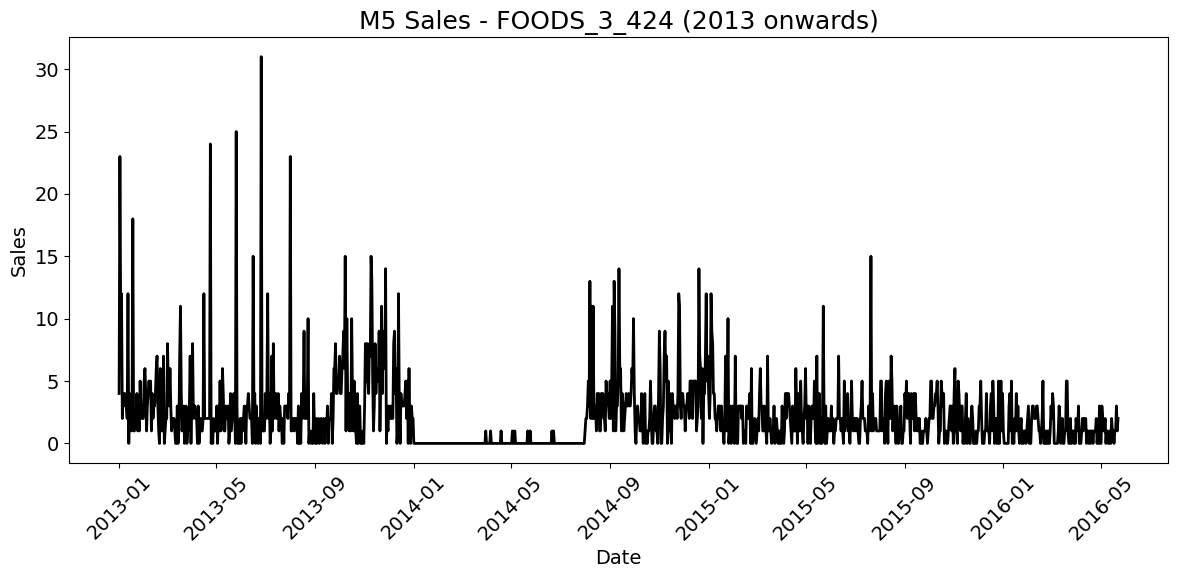

In [ ]:
# --- Figure 2.4: M5 sales FOODS_3_424 ---
fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=series_df, x="date", y="sold", color=custom_palette[0])
ax.set_xlabel('Date')
ax.set_ylabel('Sales')
ax.set_title('M5 Sales - FOODS_3_424 (2013 onwards)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Define the gap period
gap_start = '2014-01-01'
gap_end = '2014-08-01'

gap_mask = (series_df['date'] >= gap_start) & (series_df['date'] < gap_end)

df_imputed = series_df.copy()
df_imputed['mean_imputed'] = series_df['sold'].replace(
    0, df_imputed['sold'].mean())


In [ ]:
def plot_imputed_sales(df, y_variable, title_suffix=""):
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.lineplot(data=df, x="date", y=y_variable, color=custom_palette[0])
    ax.set_xlabel('Date')
    ax.set_ylabel('Sales')
    ax.set_title(f'M5 Sales - FOODS_3_424 (2013 onwards) - {title_suffix}')
    ax.axvspan(gap_start, gap_end, color='#b512b8', alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


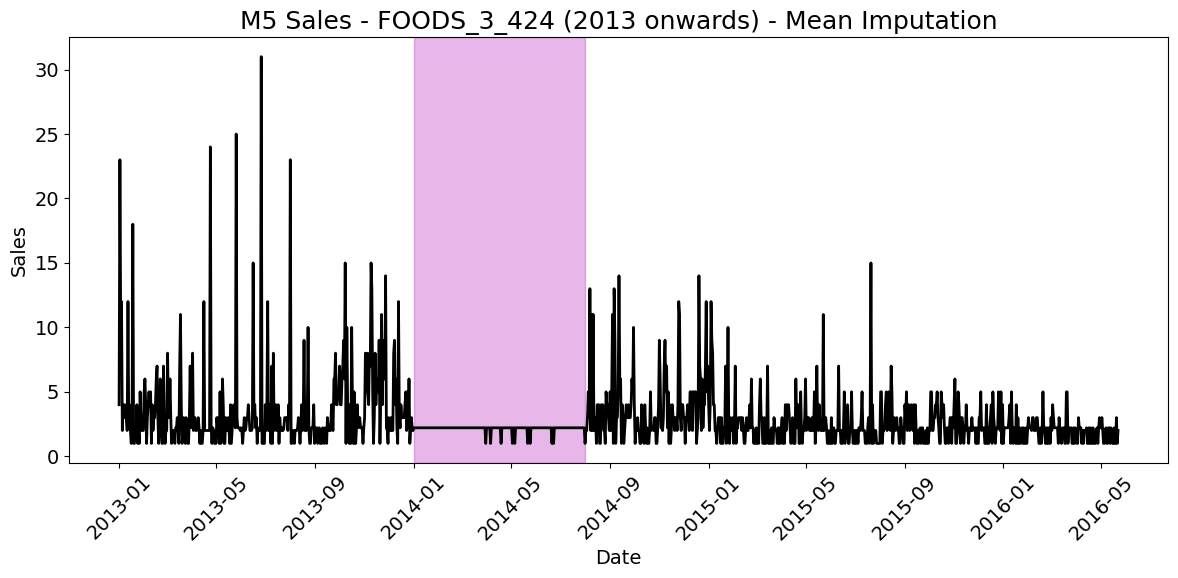

In [ ]:
# --- Figure 2.4: Mean imputation ---
plot_imputed_sales(df_imputed, "mean_imputed", "Mean Imputation")

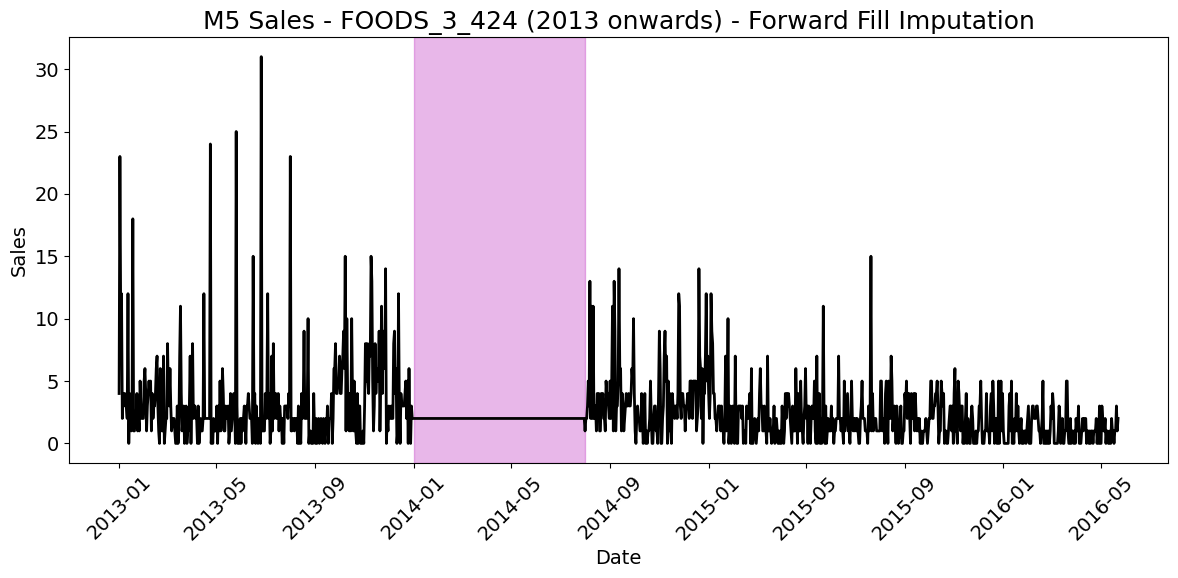

In [ ]:
# --- Figure 2.5: Forward fill ---
df_imputed['ffill_imputed'] = df_imputed['sold'].copy()
df_imputed.loc[gap_mask, 'ffill_imputed'] = (
    df_imputed.loc[~gap_mask, 'sold'].iloc[-1])
plot_imputed_sales(df_imputed, "ffill_imputed", "Forward Fill Imputation")

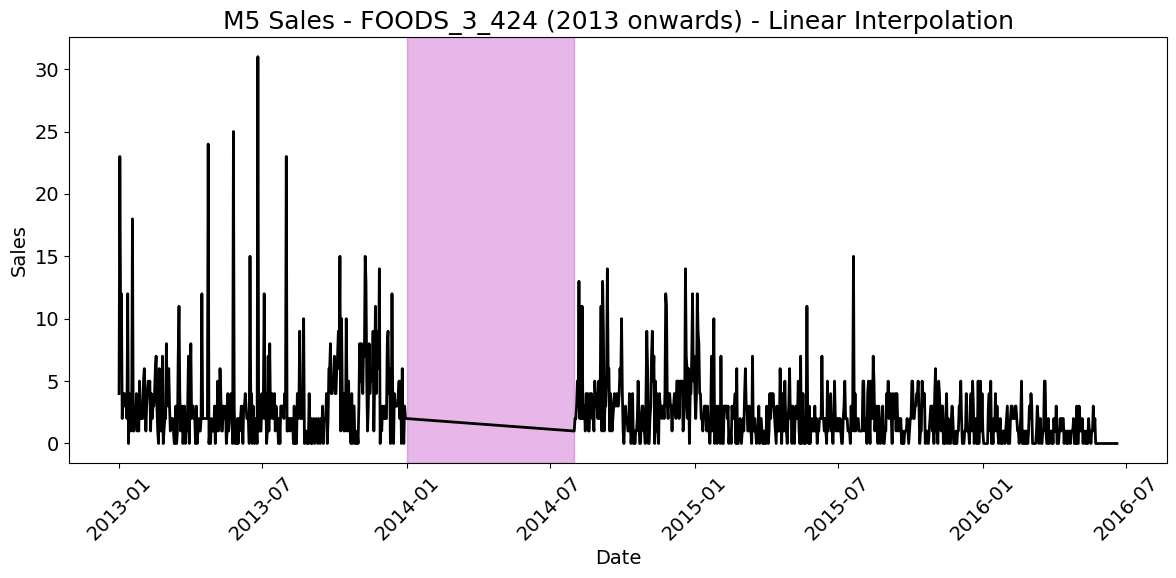

In [ ]:
# --- Figure 2.6: Linear interpolation ---
df_imputed['interp_imputed'] = df_imputed['sold'].copy()
df_imputed.loc[gap_mask, 'interp_imputed'] = np.nan
df_imputed['interp_imputed'] = df_imputed['interp_imputed'].interpolate()
plot_imputed_sales(df_imputed, "interp_imputed", "Linear Interpolation")

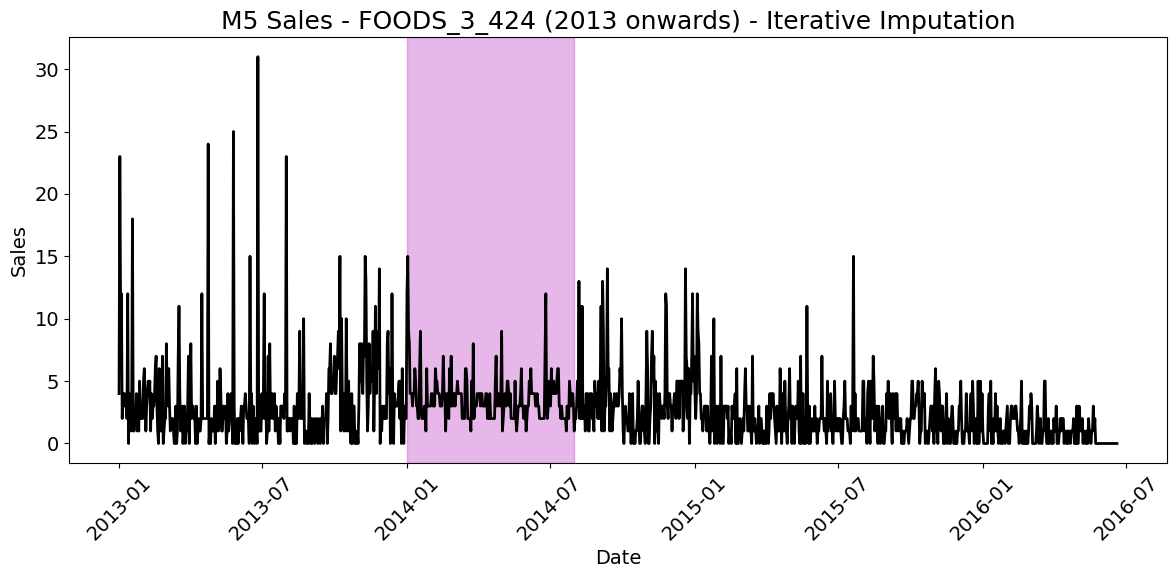

In [ ]:
# =============================================================================
# 2.5  MICE imputation with Random Forest
# =============================================================================

df_imputed['year'] = df_imputed['date'].dt.year
df_imputed['month'] = df_imputed['date'].dt.month
df_imputed['day'] = df_imputed['date'].dt.day
df_imputed['dayofweek'] = df_imputed['date'].dt.dayofweek
df_imputed['is_weekend'] = df_imputed['dayofweek'].isin([5, 6]).astype(int)

mice_imputer = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=300),
    max_iter=12, random_state=3962)

columns_for_imputation = ['sold', 'year', 'month', 'day',
                          'dayofweek', 'is_weekend']
df_mice_impute = df_imputed[columns_for_imputation].copy()
df_mice_impute.loc[gap_mask, 'sold'] = np.nan

imputed_data = mice_imputer.fit_transform(df_mice_impute)

df_imputed['mice_imputed'] = df_imputed['sold'].copy()
df_imputed.loc[gap_mask, 'mice_imputed'] = (
    imputed_data[gap_mask, 0].astype(df_imputed['sold'].dtype))

# --- Figure 2.7: MICE imputation ---
plot_imputed_sales(df_imputed, "mice_imputed", "Iterative Imputation")


## Time Series Decomposition

In [ ]:
df_imputed = df_imputed.set_index('date')

end_date = df_imputed.index[-1]
start_date = end_date - pd.DateOffset(years=1) #
df_sliced = df_imputed.loc[start_date:end_date]

decomposition = sm.tsa.seasonal_decompose(
    df_sliced['mice_imputed'], period=28, model='additive')


def plot_component(data, title, color, plot_type='line'):
    plt.figure(figsize=(12, 4))
    if plot_type == 'line':
        plt.plot(data, color=color, linewidth=2)
    elif plot_type == 'scatter':
        plt.scatter(data.index, data, color=color, s=5)
    plt.title(title)
    plt.tight_layout()
    plt.show()


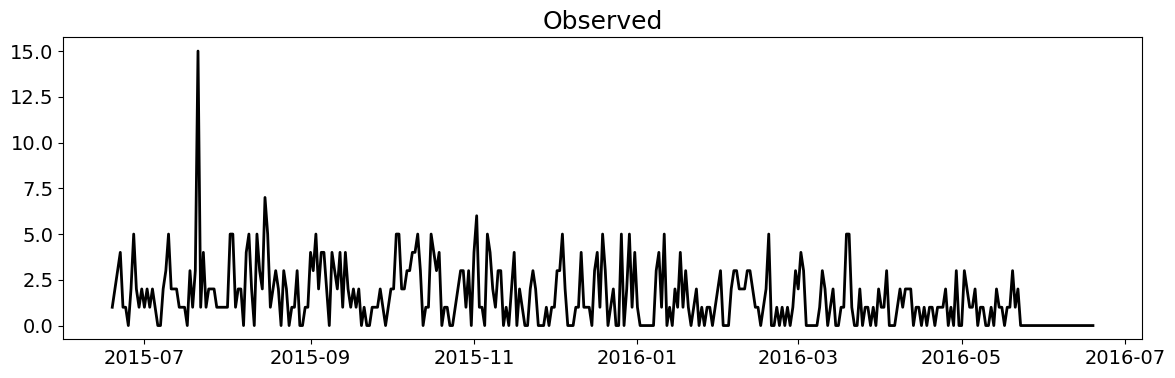

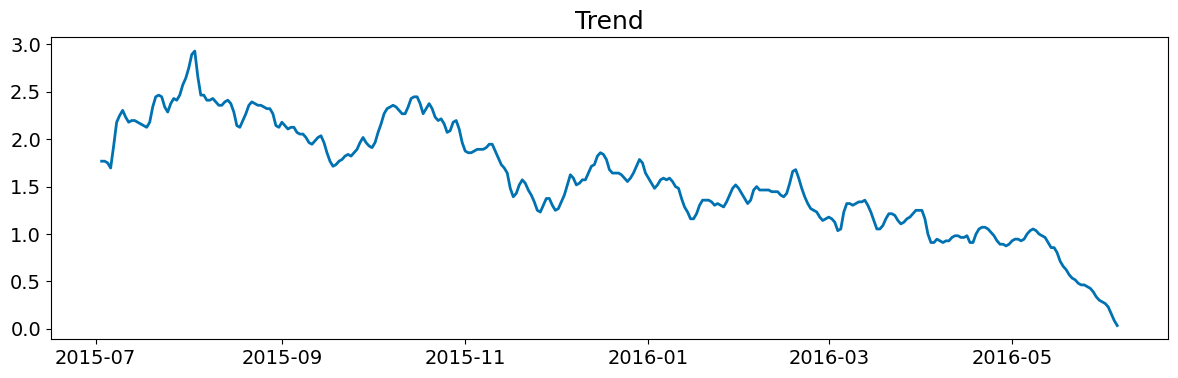

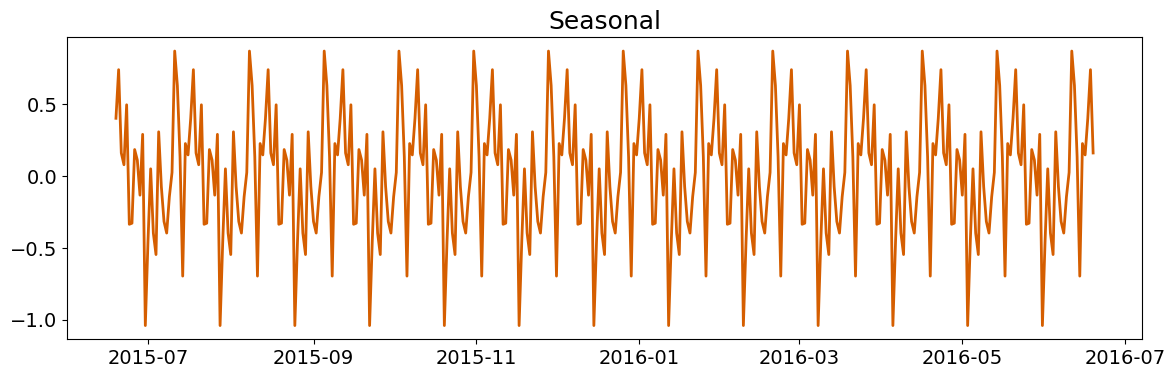

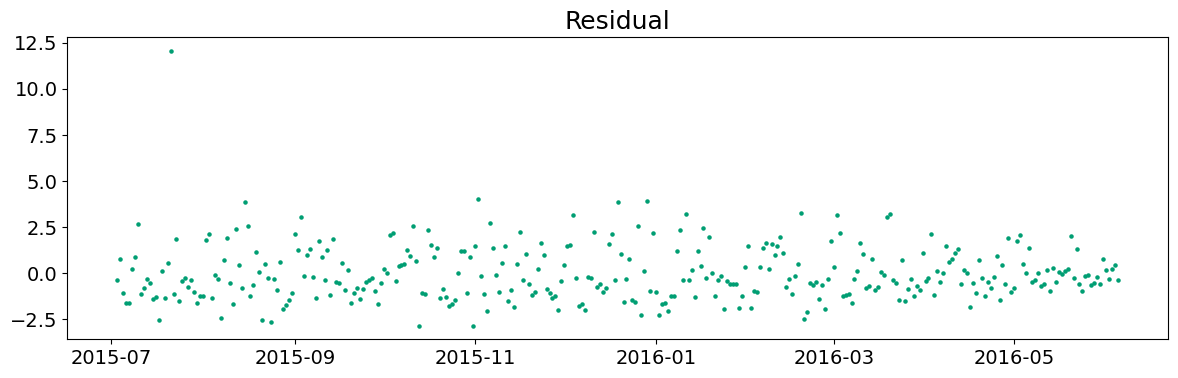

In [ ]:
# --- Figures 2.7–2.10: Decomposition components ---
plot_component(decomposition.observed, 'Observed', custom_palette[0])
plot_component(decomposition.trend, 'Trend', custom_palette[1])
plot_component(decomposition.seasonal, 'Seasonal', custom_palette[2])
plot_component(decomposition.resid, 'Residual', custom_palette[3],
               plot_type='scatter')

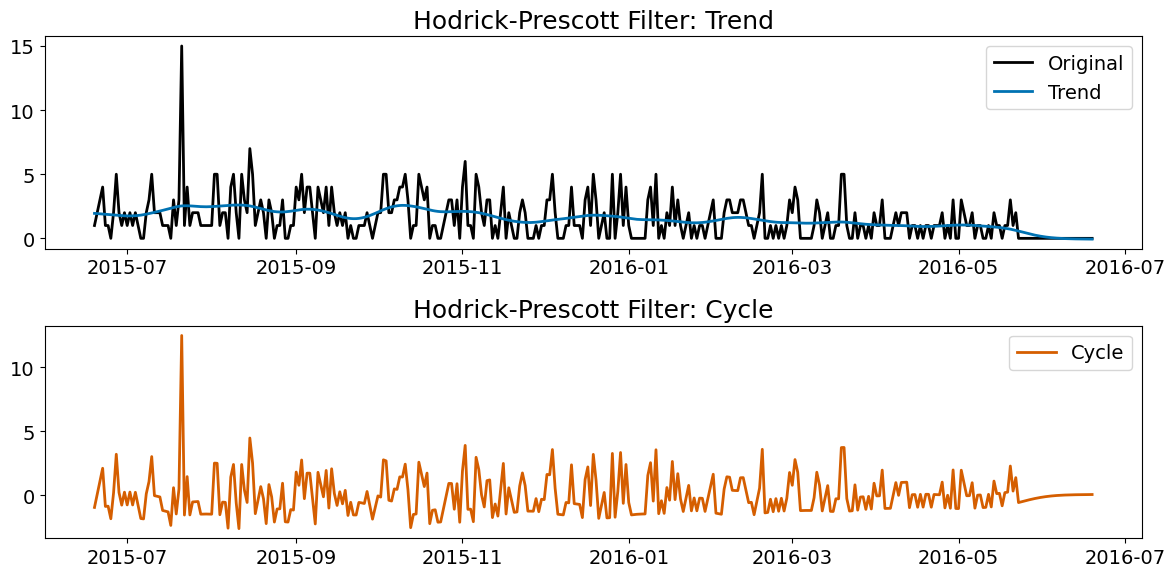

In [ ]:
# =============================================================================
# 2.8  Hodrick-Prescott filter
# =============================================================================

cycle, trend = hpfilter(df_sliced['mice_imputed'], lamb=1600)

# --- Figure 2.11: HP filter ---
plt.figure(figsize=(CFG.img_dim1, CFG.img_dim2))
plt.subplot(211)
plt.plot(df_sliced['mice_imputed'], label='Original', color=custom_palette[0])
plt.plot(trend, label='Trend', color=custom_palette[1])
plt.legend()
plt.title('Hodrick-Prescott Filter: Trend')

plt.subplot(212)
plt.plot(cycle, label='Cycle', color=custom_palette[2])
plt.legend()
plt.title('Hodrick-Prescott Filter: Cycle')
plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# 2.9  Johnson & Johnson decomposition examples
# =============================================================================

jj = sm.datasets.get_rdataset("JohnsonJohnson", "datasets")
jj_data = jj.data


In [ ]:
jj_data.head()

,time,value
0,1960.00,0.71
1,1960.25,0.63
2,1960.50,0.85
3,1960.75,0.44
4,1961.00,0.61


In [ ]:
def decimal_year_to_date(decimal_year):
    year = int(decimal_year)
    quarter = int(round((decimal_year - year) * 4)) + 1
    month = (quarter - 1) * 3 + 1
    return pd.Timestamp(year=year, month=month, day=1)


In [ ]:
jj_data['proper_date'] = jj_data['time'].apply(decimal_year_to_date)
jj_series = pd.Series(jj_data['value'].values, index=jj_data['proper_date'])

In [ ]:
jj_series.head()

,0
proper_date,
1960-01-01,0.71
1960-04-01,0.63
1960-07-01,0.85
1960-10-01,0.44
1961-01-01,0.61


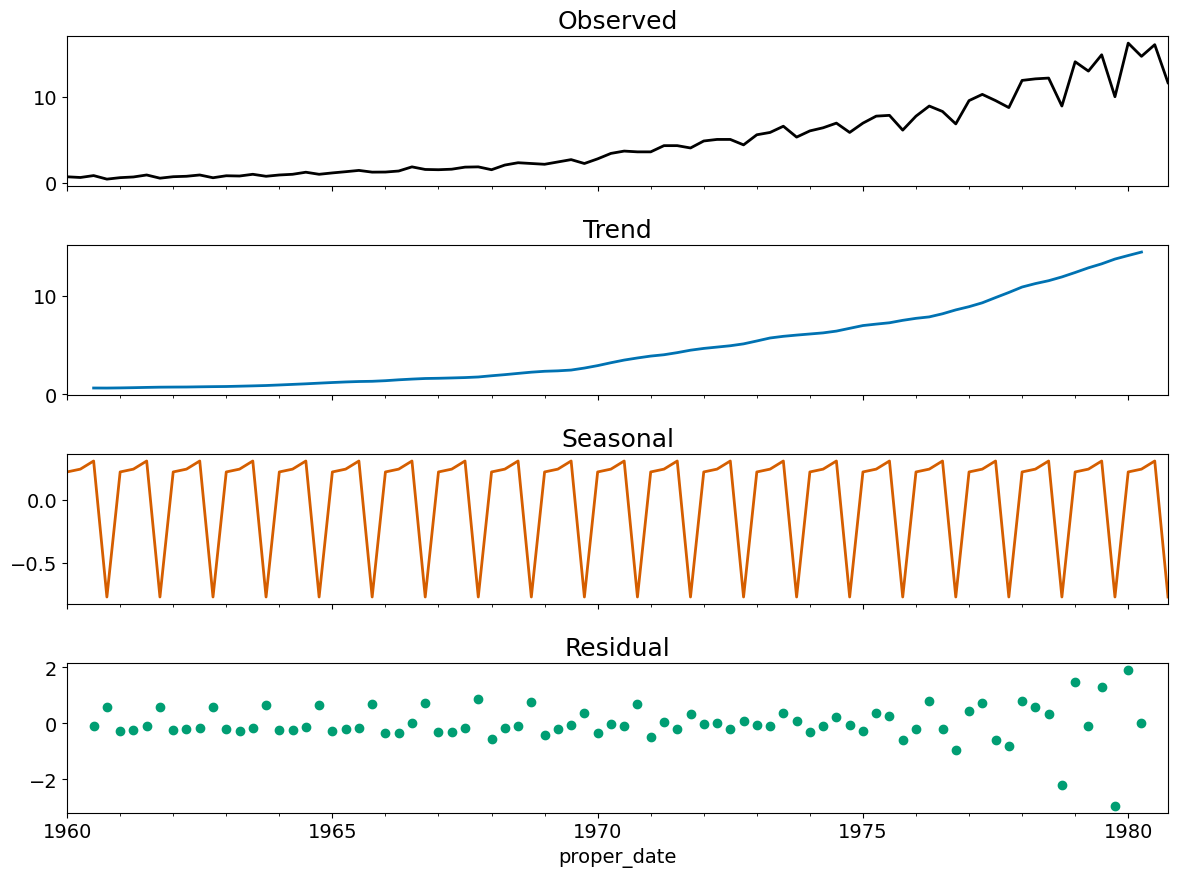

In [ ]:
# --- Figure 2.12: J&J additive decomposition ---
decomposition_add = sm.tsa.seasonal_decompose(
    jj_series, period=4, model='additive')
fig = plt.figure(figsize=(CFG.img_dim1, CFG.img_dim2 * 1.5))
axes = fig.subplots(4, 1, sharex=True)
decomposition_add.observed.plot(ax=axes[0], title='Observed',
                                color=custom_palette[0])
decomposition_add.trend.plot(ax=axes[1], title='Trend',
                             color=custom_palette[1])
decomposition_add.seasonal.plot(ax=axes[2], title='Seasonal',
                                color=custom_palette[2])
decomposition_add.resid.plot(ax=axes[3], title='Residual',
                             style='o', color=custom_palette[3])
plt.tight_layout()
plt.show()


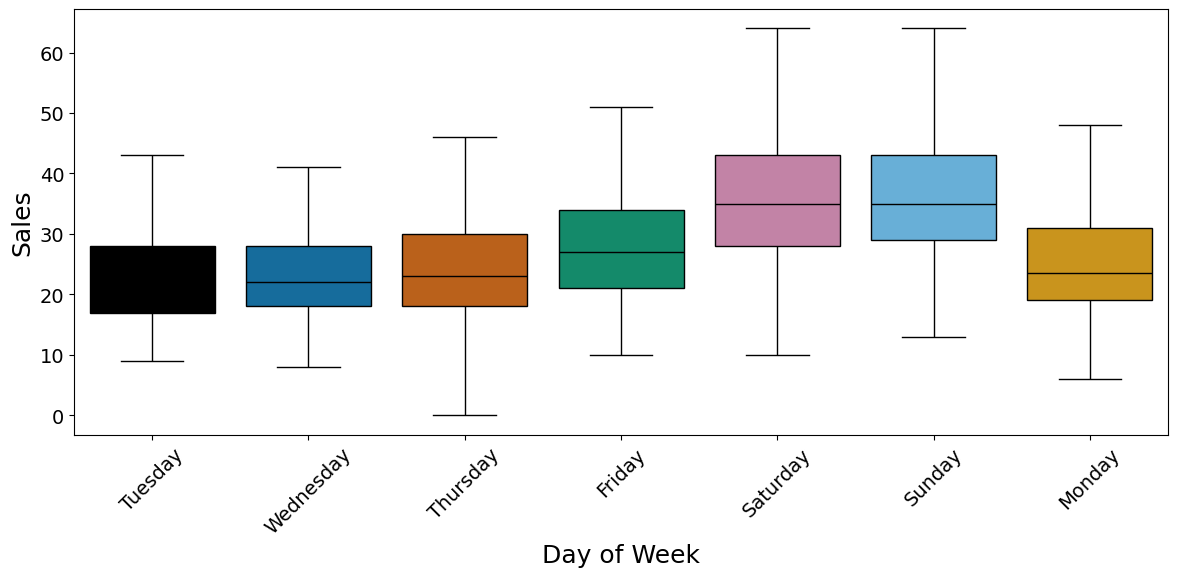

In [ ]:
# =============================================================================
# 2.10  Seasonality box plots
# =============================================================================

# Switch to FOODS_3_714 for cleaner seasonality
series_df = panel_df.loc[panel_df.item_id == 'FOODS_3_714'].copy()
series_df = series_df[series_df['date'].dt.year >= 2013].copy()
series_df = series_df.reset_index()

series_df['dayofweek'] = series_df['date'].dt.day_name()
series_df['month'] = series_df['date'].dt.month_name()
series_df['week_of_year'] = series_df['date'].dt.isocalendar().week
series_df['year'] = series_df['date'].dt.isocalendar().year

# --- Figure 2.14: Day of week ---
plt.figure(figsize=(CFG.img_dim1, CFG.img_dim2))
sns.boxplot(x='dayofweek', y='sold', data=series_df,
            hue='dayofweek', palette=custom_palette, showfliers=False,
            legend=False)
plt.xlabel('Day of Week', fontsize=18)
plt.ylabel('Sales', fontsize=18)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Lag feature creating

In [ ]:

series_df['lag_1'] = series_df['sold'].shift(1)
series_df['lag_2'] = series_df['sold'].shift(2)
series_df['lag_3'] = series_df['sold'].shift(3)
series_df['lag_4'] = series_df['sold'].shift(4)
series_df['lag_5'] = series_df['sold'].shift(5)
series_df['lag_6'] = series_df['sold'].shift(6)
series_df['lag_7'] = series_df['sold'].shift(7)

print(series_df[['date', 'sold', 'lag_1', 'lag_2', 'lag_3',
                 'lag_4', 'lag_5', 'lag_6', 'lag_7']].head(n=10))

        date  sold  lag_1  lag_2  lag_3  lag_4  lag_5  lag_6  lag_7
0 2013-01-01    17    NaN    NaN    NaN    NaN    NaN    NaN    NaN
1 2013-01-02    16   17.0    NaN    NaN    NaN    NaN    NaN    NaN
2 2013-01-03    24   16.0   17.0    NaN    NaN    NaN    NaN    NaN
3 2013-01-04    26   24.0   16.0   17.0    NaN    NaN    NaN    NaN
4 2013-01-05    21   26.0   24.0   16.0   17.0    NaN    NaN    NaN
5 2013-01-06    21   21.0   26.0   24.0   16.0   17.0    NaN    NaN
6 2013-01-07    16   21.0   21.0   26.0   24.0   16.0   17.0    NaN
7 2013-01-08    19   16.0   21.0   21.0   26.0   24.0   16.0   17.0
8 2013-01-09    18   19.0   16.0   21.0   21.0   26.0   24.0   16.0
9 2013-01-10    12   18.0   19.0   16.0   21.0   21.0   26.0   24.0


In [ ]:
# =============================================================================
# 2.12  Autocorrelation and partial autocorrelation
# =============================================================================

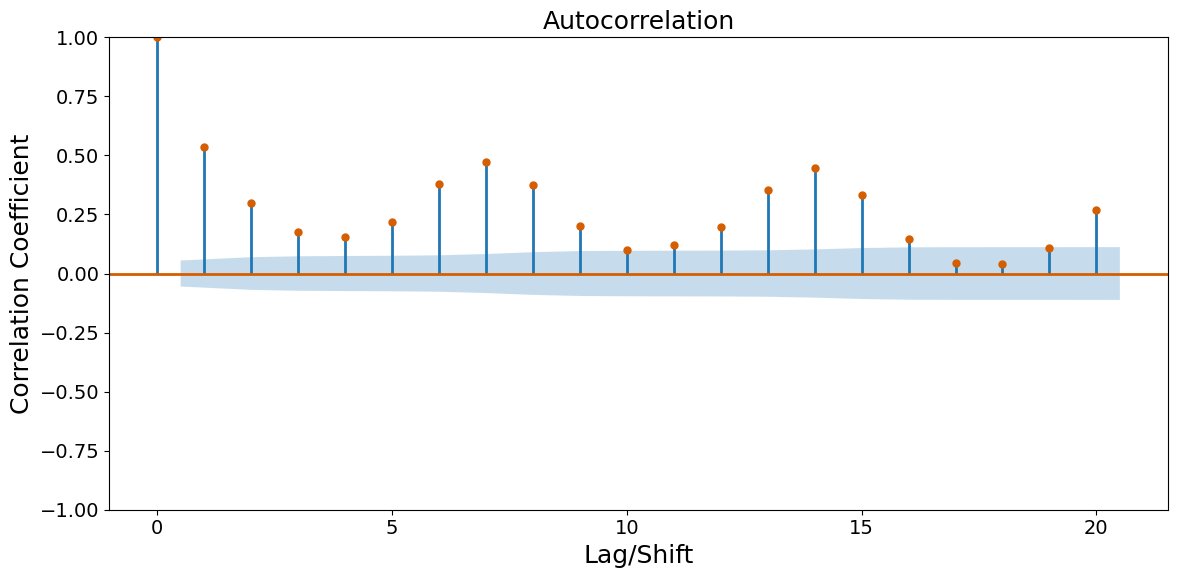

In [ ]:
# --- Figure 2.18: ACF ---
fig = plot_acf(series_df['sold'], lags=20, color=custom_palette[2])
plt.xlabel('Lag/Shift', fontsize=18)
plt.ylabel('Correlation Coefficient', fontsize=18)
plt.tight_layout()
plt.show()


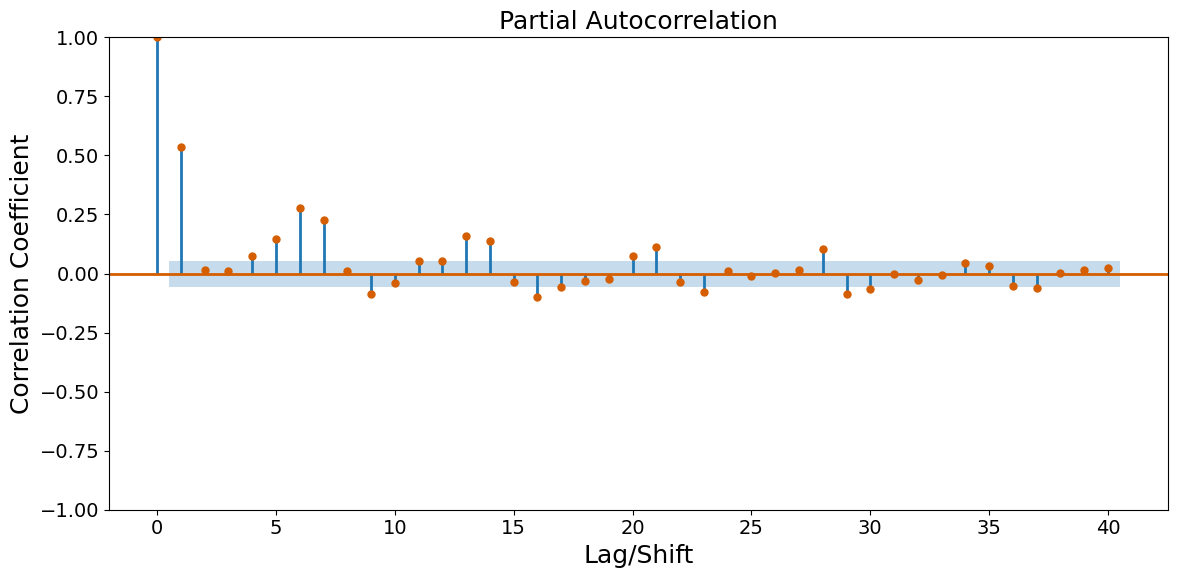

In [ ]:
# --- Figure 2.19: PACF ---
plot_pacf(series_df['sold'], lags=40, color=custom_palette[2])
plt.xlabel('Lag/Shift', fontsize=18)
plt.ylabel('Correlation Coefficient', fontsize=18)
plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# 2.13  OLS regression of features
# =============================================================================

series_df = series_df.dropna().copy()
X = series_df[['sell_price', 'dayofweek', 'month', 'week_of_year', 'year',
               'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7']]
X = pd.get_dummies(X, columns=['month', 'dayofweek'], drop_first=True)
X = X.apply(pd.to_numeric, errors='coerce')
X = sm.add_constant(X)
X = X.astype(float)

y = series_df['sold']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   sold   R-squared:                       0.508
Model:                            OLS   Adj. R-squared:                  0.498
Method:                 Least Squares   F-statistic:                     47.16
Date:                Fri, 04 Sep 2026   Prob (F-statistic):          1.55e-168
Time:                        09:05:33   Log-Likelihood:                -4460.9
No. Observations:                1259   AIC:                             8978.
Df Residuals:                    1231   BIC:                             9122.
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                1178.2123    

In [ ]:
# =============================================================================
# 2.15  Stationarity – air passengers
# =============================================================================

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving passengers.csv to passengers.csv


In [ ]:
series = pd.read_csv(CFG.data_folder / 'passengers.csv')
series['date'] = pd.to_datetime(series['date'])

In [ ]:
series.isnull().sum().sum()

np.int64(0)

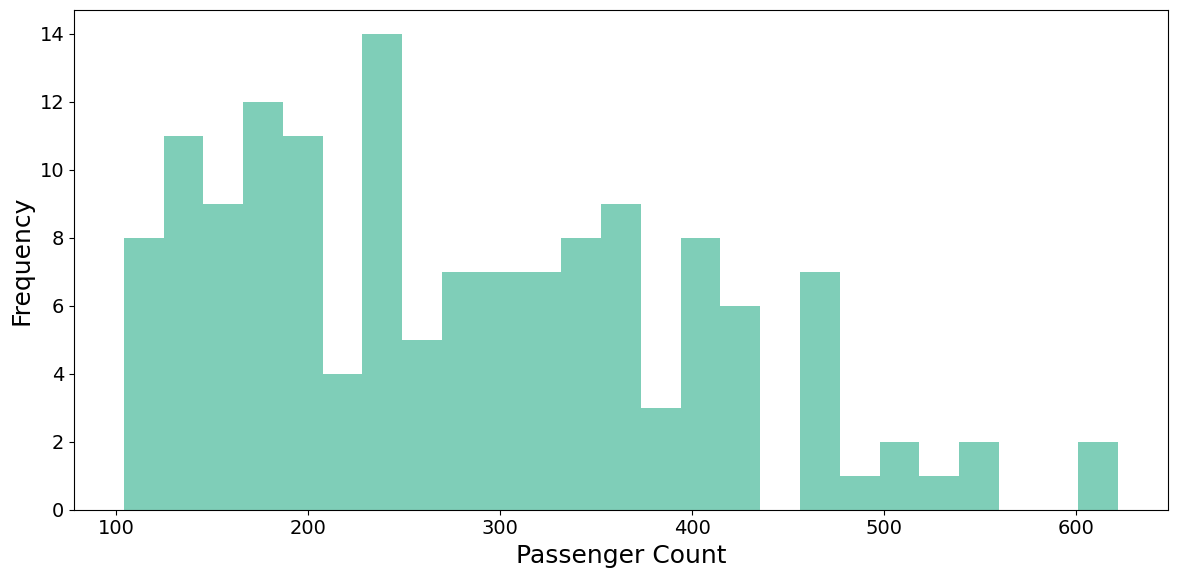

In [ ]:
# --- Figure 2.26: Passenger distribution ---
plt.figure(figsize=(12, 6))
series['passengers'].plot.hist(bins=25, alpha=0.5, color=custom_palette[3])
plt.xlabel('Passenger Count', fontsize=18)
plt.ylabel('Frequency', fontsize=18)
plt.tight_layout()
plt.show()


In [ ]:
# --- Split check ---
X = series.passengers.values
split = int(len(X) / 2)
X1, X2 = X[0:split], X[split:]
mean1, mean2 = X1.mean(), X2.mean()
var1, var2 = X1.var(), X2.var()
print('mean:')
print('chunk1: %.2f vs chunk2: %.2f' % (mean1, mean2))
print('variance:')
print('chunk1: %.2f vs chunk2: %.2f' % (var1, var2))

mean:
chunk1: 182.90 vs chunk2: 377.69
variance:
chunk1: 2244.09 vs chunk2: 7367.96


In [ ]:
# =============================================================================
# 2.16  KPSS test and transformations
# =============================================================================

X = series.passengers.values
result = kpss(X)
print('KPSS Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[3].items():
    print('\t%s: %.3f' % (key, value))

series.set_index('date', inplace=True)


def kpss_test(series):
    result = kpss(series.dropna())
    return f'KPSS Statistic: {result[0]:.3f}, p-value: {result[1]:.3f}'


def plot_transformation(original, transformed, title):
    plt.figure(figsize=(12, 6))
    plt.plot(original, color=custom_palette[0], label='Original')
    plt.plot(transformed, color=custom_palette[1], label='Transformed')

    original_kpss = kpss_test(original)
    transformed_kpss = kpss_test(transformed)

    plt.title(f'{title}\nOriginal: {original_kpss}'
              f'\nTransformed: {transformed_kpss}')
    plt.legend()
    plt.tight_layout()
    plt.show()


KPSS Statistic: 1.651312
p-value: 0.010000
Critical Values:
	10%: 0.347
	5%: 0.463
	2.5%: 0.574
	1%: 0.739


/tmp/ipykernel_3852/2701108817.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(X)


/tmp/ipykernel_3852/2701108817.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series.dropna())
/tmp/ipykernel_3852/2701108817.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series.dropna())


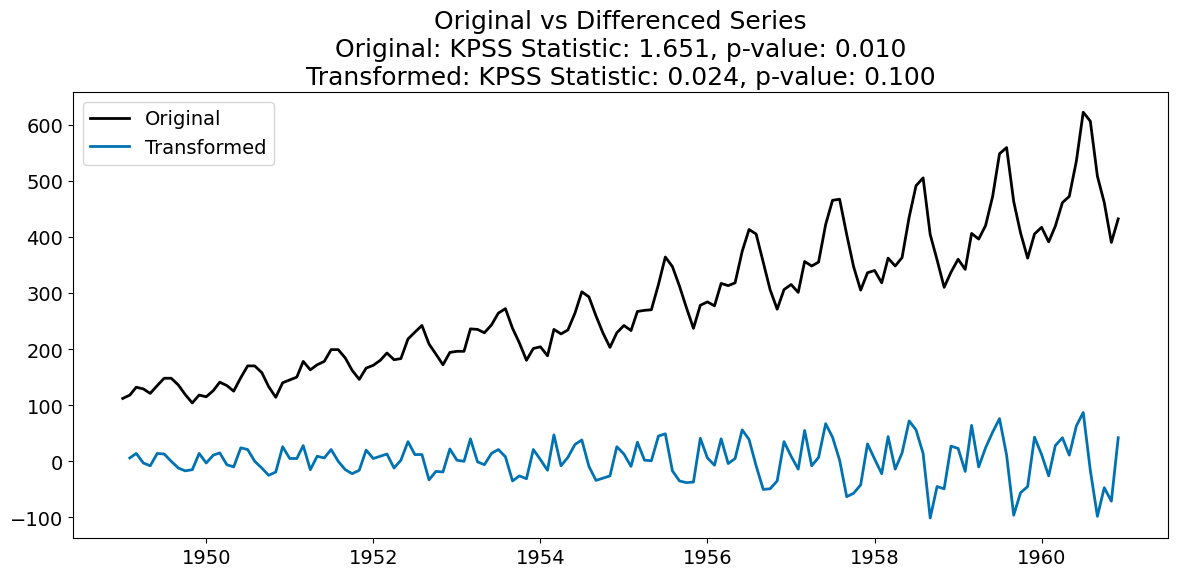

In [ ]:
# --- Figure 2.28: Differenced ---
diff_series = series.diff().dropna()
plot_transformation(series, diff_series, 'Original vs Differenced Series')

/tmp/ipykernel_3852/2701108817.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series.dropna())
/tmp/ipykernel_3852/2701108817.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series.dropna())


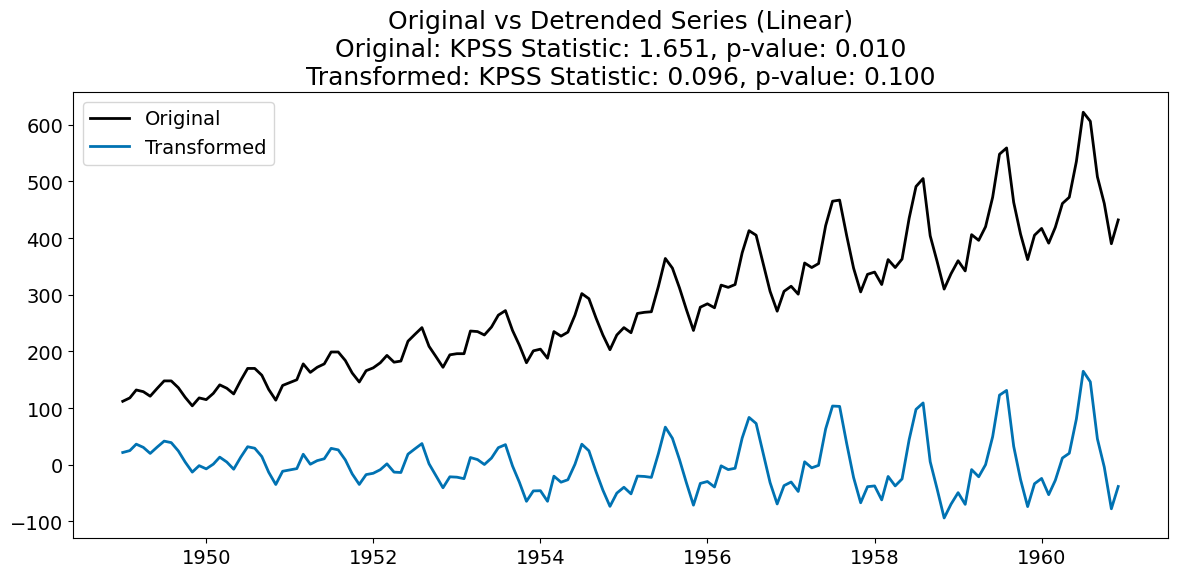

In [ ]:
# --- Figure 2.29: Detrended ---
detrend_series = pd.Series(signal.detrend(series.values.flatten()),
                           index=series.index)
plot_transformation(series, detrend_series,
                    'Original vs Detrended Series (Linear)')

/tmp/ipykernel_3852/2701108817.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series.dropna())
/tmp/ipykernel_3852/2701108817.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series.dropna())


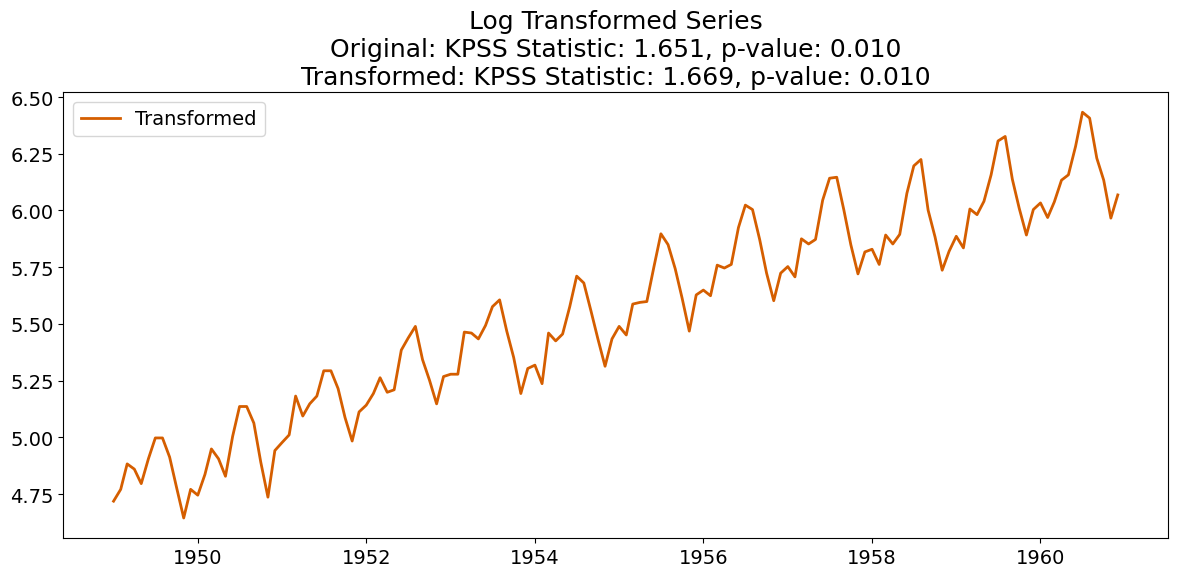

In [ ]:
# --- Figure 2.30: Log transform ---
log_series = np.log(series)
plt.figure(figsize=(12, 6))
plt.plot(log_series, color=custom_palette[2], label='Transformed')
original_kpss = kpss_test(series)
transformed_kpss = kpss_test(log_series)
plt.title(f'Log Transformed Series\nOriginal: {original_kpss}'
          f'\nTransformed: {transformed_kpss}')
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_3852/2701108817.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series.dropna())
/tmp/ipykernel_3852/2701108817.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series.dropna())


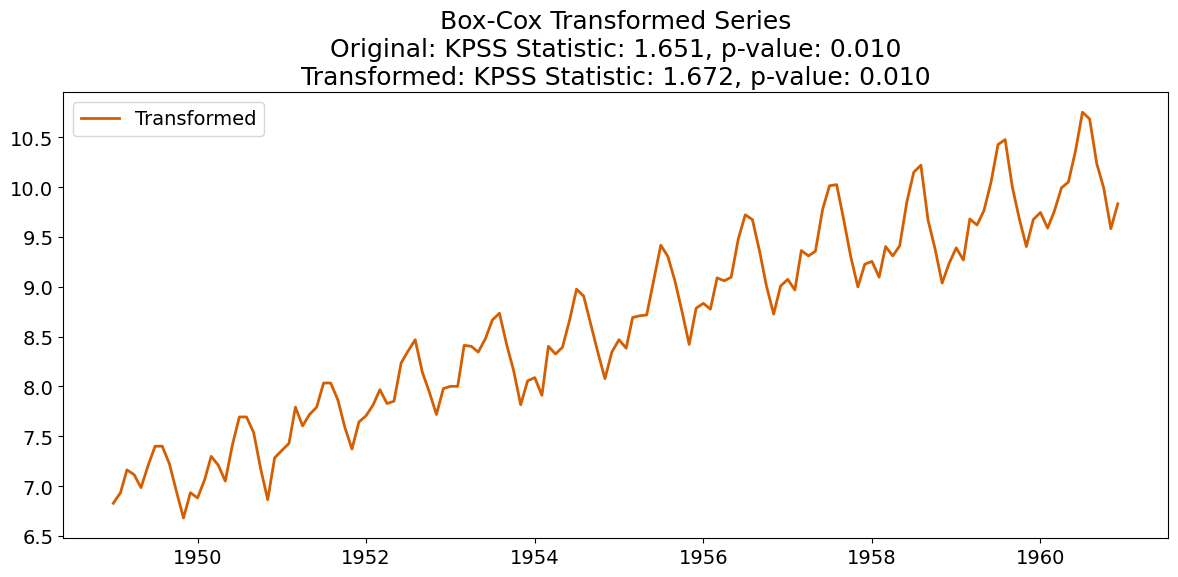

In [ ]:
# --- Figure 2.31: Box-Cox ---
bc_series, lambda_param = stats.boxcox(series.values.flatten())
bc_series = pd.Series(bc_series, index=series.index)

plt.figure(figsize=(12, 6))
plt.plot(bc_series, color=custom_palette[2], label='Transformed')
original_kpss = kpss_test(series)
transformed_kpss = kpss_test(bc_series)
plt.title(f'Box-Cox Transformed Series\nOriginal: {original_kpss}'
          f'\nTransformed: {transformed_kpss}')
plt.legend()
plt.tight_layout()
plt.show()


/tmp/ipykernel_3852/2701108817.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series.dropna())
/tmp/ipykernel_3852/2701108817.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series.dropna())


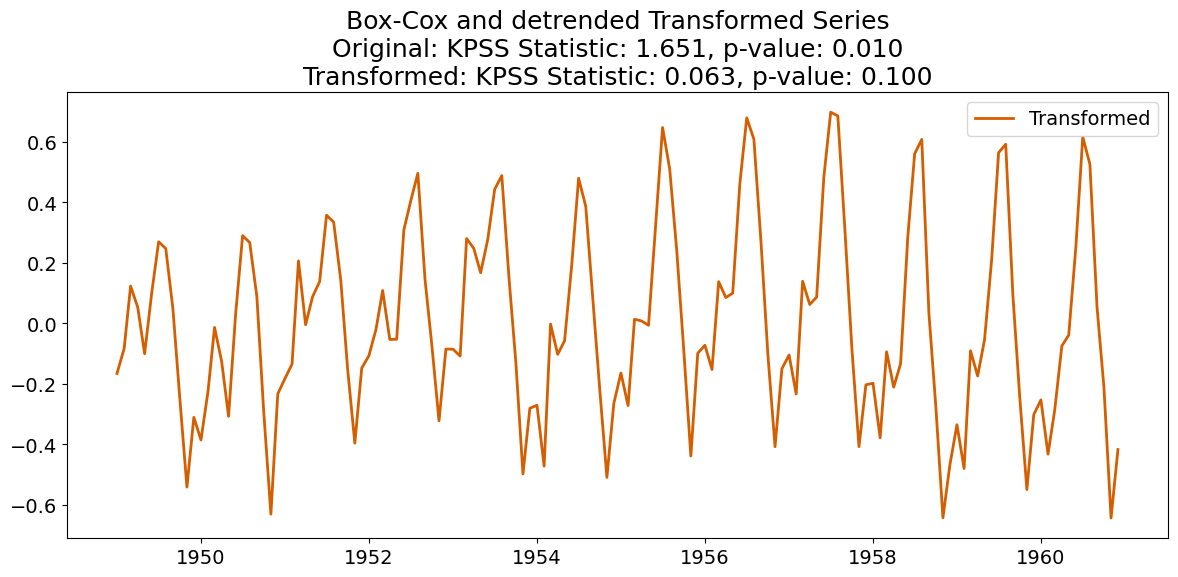

In [ ]:
# --- Figure 2.32: Box-Cox + detrend combined ---
bc_series, lambda_param = stats.boxcox(series.values.flatten())
bc_series = pd.Series(bc_series, index=series.index)
bc_detrend_series = pd.Series(signal.detrend(bc_series.values.flatten()),
                              index=bc_series.index)

plt.figure(figsize=(12, 6))
plt.plot(bc_detrend_series, color=custom_palette[2], label='Transformed')
original_kpss = kpss_test(series)
transformed_kpss = kpss_test(bc_detrend_series)
plt.title(f'Box-Cox and detrended Transformed Series\nOriginal: '
          f'{original_kpss}\nTransformed: {transformed_kpss}')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# =============================================================================
# 2.19  Multivariable time series (different frequencies)
# =============================================================================

np.random.seed(52747)

# Daily sales
daily_dates = pd.date_range(start='2020-01-01', end='2021-12-31', freq='D')
daily_trend = np.linspace(100, 150, len(daily_dates))
daily_seasonal = 20 * np.sin(2 * np.pi * np.arange(len(daily_dates)) / 7)
daily_noise = np.random.normal(0, 10, len(daily_dates))
daily_sales = daily_trend + daily_seasonal + daily_noise

# Monthly CPI
monthly_dates = pd.date_range(start='2020-01-01', end='2021-12-31', freq='M')
monthly_trend = np.linspace(100, 110, len(monthly_dates))
monthly_seasonal = 2 * np.sin(2 * np.pi * np.arange(len(monthly_dates)) / 12)
monthly_noise = np.random.normal(0, 1, len(monthly_dates))
monthly_cpi = monthly_trend + monthly_seasonal + monthly_noise

daily_df = pd.DataFrame({'Sales': daily_sales}, index=daily_dates)
monthly_df = pd.DataFrame({'CPI': monthly_cpi}, index=monthly_dates)


/tmp/ipykernel_3852/1068707204.py:15: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_dates = pd.date_range(start='2020-01-01', end='2021-12-31', freq='M')


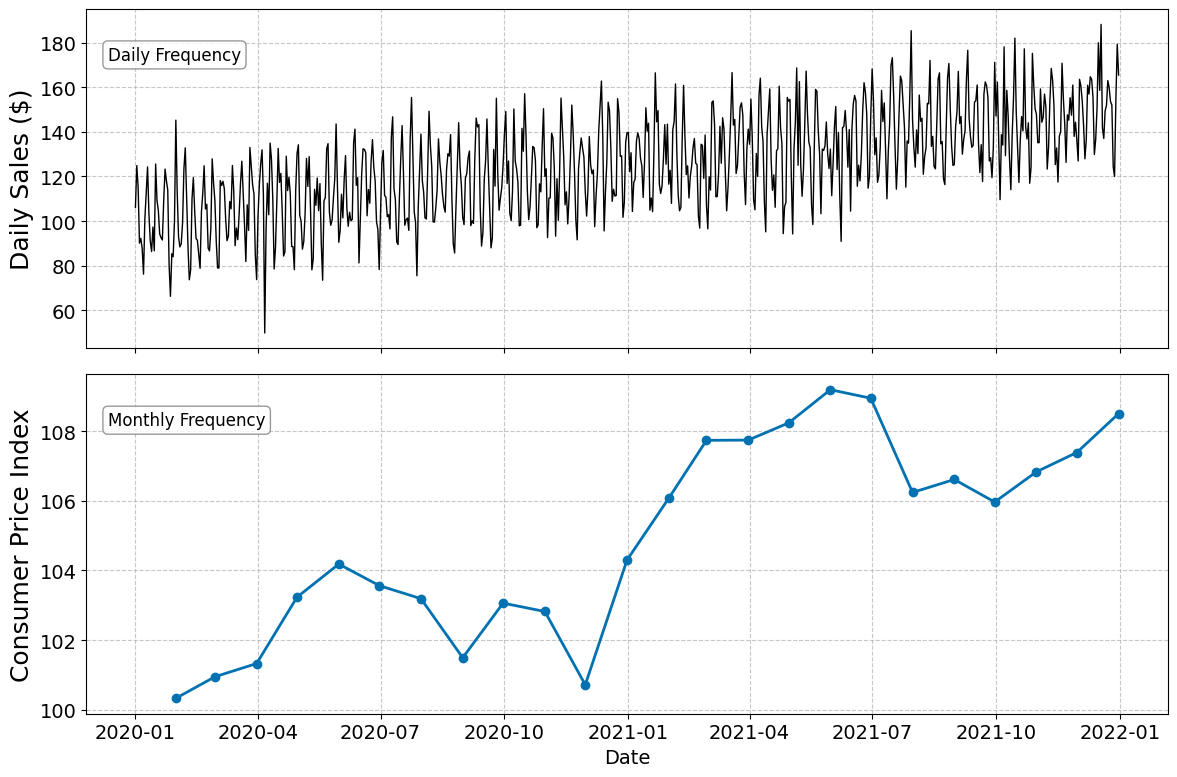

In [ ]:
# --- Figure 2.35: Multivariable ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.plot(daily_df.index, daily_df['Sales'],
         color=custom_palette[0], linewidth=1)
ax1.set_ylabel('Daily Sales ($)', fontsize=18)
ax1.grid(True, linestyle='--', alpha=0.7)

ax2.plot(monthly_df.index, monthly_df['CPI'],
         color=custom_palette[1], linewidth=2, marker='o')
ax2.set_ylabel('Consumer Price Index', fontsize=18)
ax2.set_xlabel('Date', fontsize=14)
ax2.grid(True, linestyle='--', alpha=0.7)

ax1.annotate('Daily Frequency', xy=(0.02, 0.85), xycoords='axes fraction',
             fontsize=12, bbox=dict(boxstyle="round,pad=0.3",
                                    fc="white", ec="gray", alpha=0.8))
ax2.annotate('Monthly Frequency', xy=(0.02, 0.85), xycoords='axes fraction',
             fontsize=12, bbox=dict(boxstyle="round,pad=0.3",
                                    fc="white", ec="gray", alpha=0.8))

plt.tight_layout()
plt.show()
